# Generate 3D Descriptors

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors3D, rdDistGeom
import numpy as np
from rdkit.Chem import rdMolAlign
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolTransforms
from rdkit.Chem import rdForceFieldHelpers

from rdkit.Chem import PyMol
import copy
import numpy as np

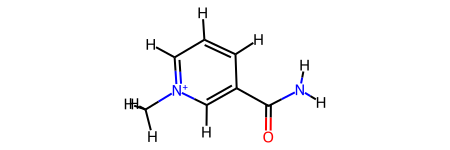

20


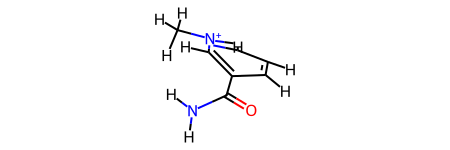

[{'PMI1': 199.4312250057102, 'PMI2': 514.4403390925085, 'PMI3': 685.1203831652984, 'NPR1': 0.29108931788647946, 'NPR2': 0.7508758339895863, 'RadiusOfGyration': 2.258269166897116, 'InertialShapeFactor': 0.0037650866055106815, 'Eccentricity': 0.9566958811515727, 'Asphericity': 0.3722260219159865, 'SpherocityIndex': 0.13210875066027863, 'PBF': 0.41979809637025306}, {'PMI1': 199.4312250057102, 'PMI2': 514.4403390925085, 'PMI3': 685.1203831652984, 'NPR1': 0.29108931788647946, 'NPR2': 0.7508758339895863, 'RadiusOfGyration': 2.258269166897116, 'InertialShapeFactor': 0.0037650866055106815, 'Eccentricity': 0.9566958811515727, 'Asphericity': 0.3722260219159865, 'SpherocityIndex': 0.13210875066027863, 'PBF': 0.41979809637025306}, {'PMI1': 199.4312250057102, 'PMI2': 514.4403390925085, 'PMI3': 685.1203831652984, 'NPR1': 0.29108931788647946, 'NPR2': 0.7508758339895863, 'RadiusOfGyration': 2.258269166897116, 'InertialShapeFactor': 0.0037650866055106815, 'Eccentricity': 0.9566958811515727, 'Asphericit

In [ ]:
# Sample on how to generate conformers for each molecule. Used to generate 3D Descriptors
# https://docs.datamol.io/stable/tutorials/Conformers.html 
mol = Chem.MolFromSmiles("C[N+]1=CC=CC(=C1)C(=O)N")
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol)
display(mol)

# Setup the parameters for the embedding
params = getattr(rdDistGeom, "ETDG")()
params.randomSeed = 135
params.enforceChirality = True
params.useRandomCoords = True
params.numThreads = 5 #cpu threads

# Embed conformers
confs = rdDistGeom.EmbedMultipleConfs(mol, numConfs=20, params=params) #We ask for 50 different 3-D poses.

print(len(confs))
print(confs)
display(mol)

desc = [Descriptors3D.CalcMolDescriptors3D(mol=mol, confId=cid) for cid in confs]
print(desc)

In [ ]:
params = rdDistGeom.ETDG()          # ETDG defaults
params.randomSeed       = 3
params.enforceChirality = True
params.useRandomCoords  = True
params.numThreads       = 4         # <= CPU cores

rows = []

for _, r in master_df.iterrows():
    gid, smi = r["g_id"], r["smi"]
    
    # --- build & embed ---
    mol  = Chem.AddHs(Chem.MolFromSmiles(smi))
    cids = rdDistGeom.EmbedMultipleConfs(mol, numConfs=20, params=params)
    if not cids: # rare but can happen with broken SMILES
        continue
    
    # --- energy minimisation (UFF) ---
    opt = rdForceFieldHelpers.UFFOptimizeMoleculeConfs(mol, maxIters=200, numThreads=4)
    energies = np.array([e for _, e in opt])       # optimisation returns (iters, E)
    
    # --- tag energies on each conformer ---
    for cid, e in zip(cids, energies):
        mol.GetConformer(cid).SetDoubleProp("uff_energy", float(e))
    
    # --- sort conformers by energy (lowest first) ---
    order = energies.argsort()
    mol_sorted = Chem.Mol(mol)        # shallow copy keeps props
    mol_sorted.RemoveAllConformers()
    for cid in order:
        conf_copy = Chem.Conformer(mol.GetConformer(int(cid)))
        mol_sorted.AddConformer(conf_copy, assignId=True)
    
    # --- descriptors from *lowest-energy* conformer (id 0 after sort) ---
    desc = Descriptors3D.CalcMolDescriptors3D(mol_sorted, confId=0)
    desc["g_id"]  = gid
    desc["smiles"] = smi
    rows.append(desc)

# ---------- new dataframe ----------
desc_df = pd.DataFrame(rows).set_index("g_id")
desc_df.to_csv("3d.csv")
print(desc_df.head())

[00:29:03] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[00:29:03] UFFTYPER: Unrecognized atom type: Co2+3 (92)
[00:33:47] UFFTYPER: Unrecognized charge state for atom: 1
[00:33:48] UFFTYPER: Unrecognized charge state for atom: 1
[00:40:39] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[00:40:39] UFFTYPER: Unrecognized atom type: Co2+3 (91)
[00:42:59] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[00:42:59] UFFTYPER: Unrecognized atom type: Co2+3 (92)
[01:54:41] UFFTYPER: Unrecognized charge state for atom: 1
[01:54:41] UFFTYPER: Unrecognized charge state for atom: 1
[01:54:57] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[01:54:57] UFFTYPER: Unrecognized atom type: Ca+2 (34)
[01:55:03] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[01:55:03] UFFTYPER: Unrecognized atom type: Ca+2 (30)
[01:57:25] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[01:57:25] UFFTYPER: Unrecognized atom type: Co2+3 (92)
[02:02:57] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[02:02:57] UFFTYPER: Unrecognized atom type: Co

KeyboardInterrupt: 